# Batch density fits for phase-separated thermalized states

This notebook discovers every V3 thermalization state whose saved voxel classification is phase separated, fits its gas/liquid/interface voxel histogram with the **same pooled-tail routine used for cavitation states**, and writes a resumable CSV.

For each state, it reports the fitted gas density, fitted liquid density, and liquid/gas density ratio. Standard errors and 95% confidence intervals are propagated from the complete five-parameter fit covariance, including parameter correlations.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers.paths import MASTER_CSVS_V3_ROOT, THERMALIZED_STATES_V3_ROOT
from md_Helpers.phase_density import (
    analyze_phase_separated_thermalized_states,
    discover_phase_separated_thermalized_states,
    plot_density_ratio_with_uncertainty,
    select_phase_density_results,
)

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

## 1. Batch settings

These are the cavitation voxel-fit defaults: five tail frames, five-frame spacing, final half of the trajectory, 40 interface quadrature points, and a 50/50 interface allocation. `voxel_nbins=None` applies the repository's `ncell`-dependent Seitz resolution rule.

In [4]:
THERMALIZED_ROOT = Path(THERMALIZED_STATES_V3_ROOT)
OUTPUT_CSV = Path(MASTER_CSVS_V3_ROOT) / "thermalized_phase_density_fits.csv"

VOXEL_NBINS = None
NFRAMES = 5
FRAME_SKIP = 5
TAIL_FRACTION = 0.5
INTERFACE_VOID_FRACTION = 0.5
INTERFACE_POINTS = 40
MAX_FIT_ITERATIONS = 500

print(f"Thermalized root: {THERMALIZED_ROOT}")
print(f"Resumable output: {OUTPUT_CSV}")

Thermalized root: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3
Resumable output: /exp/e961/data/MDsims-data/pnichols/Master_CSVs_v3/thermalized_phase_density_fits.csv


## 2. Discover classified phase-separated states

This reads existing HDF5 classification metadata. It does not reclassify states or run simulations.

In [5]:
phase_states = discover_phase_separated_thermalized_states(
    root=THERMALIZED_ROOT
)
print(f"Discovered {len(phase_states)} phase-separated thermalized states")
display(phase_states)

Discovered 268 phase-separated thermalized states


,n_fcc_cells,target_rho,actual_rho,kT,nsteps,seed,phase_name,phase_separated,phase_sep_low_density_fraction,state_path,log_path,state_exists
0,10,0.500,0.500,0.7,1000000,1,randomization,True,0.273148,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
1,10,0.550,0.550,0.7,1000000,1,randomization,True,0.226852,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
2,10,0.600,0.600,0.7,1000000,1,randomization,True,0.175926,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
3,10,0.650,0.650,0.7,1000000,1,randomization,True,0.115741,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
4,10,0.700,0.700,0.7,1000000,1,randomization,True,0.055556,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
...,...,...,...,...,...,...,...,...,...,...,...,...
263,30,0.520,0.520,1.0,1000000,1,randomization,True,0.141782,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
264,30,0.540,0.540,1.0,1000000,1,randomization,True,0.108796,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
265,30,0.560,0.560,1.0,1000000,1,randomization,True,0.070602,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True
266,30,0.580,0.580,1.0,1000000,1,randomization,True,0.041088,/exp/e961/data/MDsims-data/pnichols/Thermalize...,/exp/e961/data/MDsims-data/pnichols/Thermalize...,True


## 3. Fit every discovered state

The CSV is checkpointed after every state. With `resume=True`, completed fits with identical analysis settings are reused on the next run. Failed fits are attempted again.

Legacy thermalization `randomization.gsd` files often contain one frame. The exact cavitation fitter is still used, but `frames_available` and `frames_fitted` will be 1 for those files.

In [6]:
results = analyze_phase_separated_thermalized_states(
    states=phase_states,
    output_path=OUTPUT_CSV,
    voxel_nbins=VOXEL_NBINS,
    nframes=NFRAMES,
    skip=FRAME_SKIP,
    tail_fraction=TAIL_FRACTION,
    interface_void_fraction=INTERFACE_VOID_FRACTION,
    interface_points=INTERFACE_POINTS,
    max_iterations=MAX_FIT_ITERATIONS,
    resume=True,
)

print(results["status"].value_counts(dropna=False))
print(f"Saved {len(results)} rows to {OUTPUT_CSV}")

[1/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.500/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[2/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.550/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[3/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.600/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[4/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.650/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[5/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.700/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[6/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.725/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
[7/268] cached: /exp/e961/data/MDsims-data/pnichols/Thermalized_States_v3/FCC/n_cells_10/rho_0.730/kT_0.700/nste

In [7]:
quality_columns = [
    "n_fcc_cells", "target_rho", "kT", "seed", "status",
    "frames_available", "frames_fitted", "fit_success",
    "gas_density", "liquid_density",
    "liquid_to_gas_density_ratio", "error",
]
display(results[[column for column in quality_columns if column in results]])

failed = results[results["status"].ne("completed")]
if not failed.empty:
    print(f"WARNING: {len(failed)} fits did not complete. Inspect their error column.")

completed = results[results["status"].eq("completed")]
for column in ["n_fcc_cells", "kT", "target_rho", "seed"]:
    values = sorted(completed[column].dropna().unique())
    print(f"Available {column}: {values}")

,n_fcc_cells,target_rho,kT,seed,status,frames_available,frames_fitted,fit_success,gas_density,liquid_density,liquid_to_gas_density_ratio,error
0,10,0.500,0.7,1,completed,1,1,True,0.006693,0.475284,71.015816,NaN
1,10,0.550,0.7,1,completed,1,1,True,0.023053,0.767861,33.308924,NaN
2,10,0.600,0.7,1,completed,1,1,True,0.012959,0.789220,60.900389,NaN
3,10,0.650,0.7,1,completed,1,1,True,0.000035,0.773823,22046.245937,NaN
4,10,0.700,0.7,1,completed,1,1,True,0.030372,0.773937,25.481827,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
263,30,0.520,1.0,1,completed,1,1,True,0.064240,0.617318,9.609608,NaN
264,30,0.540,1.0,1,completed,1,1,True,0.066588,0.617429,9.272407,NaN
265,30,0.560,1.0,1,completed,1,1,True,0.063033,0.614434,9.747768,NaN
266,30,0.580,1.0,1,completed,1,1,True,0.069429,0.613014,8.829317,NaN


Available n_fcc_cells: [np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(28), np.int64(30)]
Available kT: [np.float64(0.7), np.float64(0.72), np.float64(0.74), np.float64(0.75), np.float64(0.76), np.float64(0.78), np.float64(0.8), np.float64(0.82), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.88), np.float64(0.9), np.float64(0.92), np.float64(0.94), np.float64(0.95), np.float64(0.96), np.float64(0.98), np.float64(1.0), np.float64(1.05)]
Available target_rho: [np.float64(0.5), np.float64(0.52), np.float64(0.54), np.float64(0.55), np.float64(0.56), np.float64(0.58), np.float64(0.585), np.float64(0.6), np.float64(0.62), np.float64(0.64), np.float64(0.65), np.float64(0.66), np.float64(0.68), np.float64(0.7), np.float64(0.702), np.float64(0.703), np.float64(0.705), np.float64(0.707), np.float64(0.71), np.float64(0.715), np.float64(0.72), np.float64(0.725), np.float64(0.73), np.float64(0.735), np.float64(0.74), np.float64(0.745)]
Available seed: [np.int6

## 4. Select the states to inspect

Each selector accepts a list, one scalar value, or `None` for all values. For example, use `SELECT_NCELLS = [20, 30]` or `SELECT_TEMPERATURES = [0.7, 0.8]`.

In [8]:
SELECT_NCELLS = [30]
SELECT_TEMPERATURES = None
SELECT_TARGET_DENSITIES = None
SELECT_SEEDS = None
RATIO_ERROR_BARS = "se"  # Choose "se" or "ci95".

selected = select_phase_density_results(
    results,
    ncells=SELECT_NCELLS,
    temperatures=SELECT_TEMPERATURES,
    target_densities=SELECT_TARGET_DENSITIES,
    seeds=SELECT_SEEDS,
)

selected_columns = [
    "n_fcc_cells", "target_rho", "actual_rho", "kT", "seed",
    "gas_density", "gas_density_se",
    "liquid_density", "liquid_density_se",
    "liquid_to_gas_density_ratio",
    "liquid_to_gas_density_ratio_se",
    "liquid_to_gas_density_ratio_ci95_low",
    "liquid_to_gas_density_ratio_ci95_high",
    "frames_fitted", "state_path",
]
print(f"Selected {len(selected)} completed fits")
display(selected[[column for column in selected_columns if column in selected]])

Selected 162 completed fits


,n_fcc_cells,target_rho,actual_rho,kT,seed,gas_density,gas_density_se,liquid_density,liquid_density_se,liquid_to_gas_density_ratio,liquid_to_gas_density_ratio_se,liquid_to_gas_density_ratio_ci95_low,liquid_to_gas_density_ratio_ci95_high,frames_fitted,state_path
0,30,0.500,0.500,0.70,1,0.005591,0.000337,0.804528,0.001186,143.899804,8.680254,127.853756,161.959681,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
1,30,0.520,0.520,0.70,1,0.006200,0.000385,0.806575,0.001098,130.083182,8.089614,115.155757,146.945623,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
2,30,0.540,0.540,0.70,1,0.006274,0.000401,0.806989,0.001099,128.634187,8.226848,113.479258,145.813026,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
3,30,0.560,0.560,0.70,1,0.107871,NaN,0.538491,0.009357,4.991975,NaN,NaN,NaN,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
4,30,0.580,0.580,0.70,1,0.112000,NaN,0.561667,0.008980,5.014904,NaN,NaN,NaN,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
5,30,0.600,0.600,0.70,1,0.121593,NaN,0.584605,0.008609,4.807890,NaN,NaN,NaN,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
6,30,0.620,0.620,0.70,1,0.125558,NaN,0.608095,0.008172,4.843148,NaN,NaN,NaN,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
7,30,0.640,0.640,0.70,1,0.006353,0.000635,0.802298,0.001052,126.279064,12.622621,103.811451,153.609276,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
8,30,0.660,0.660,0.70,1,0.006176,0.000687,0.802799,0.001044,129.979868,14.458247,104.518066,161.644458,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...
9,30,0.680,0.680,0.70,1,0.005162,0.000748,0.801634,0.001032,155.296209,22.514160,116.884020,206.331991,1,/exp/e961/data/MDsims-data/pnichols/Thermalize...


## 5. Filtered gas and liquid density plots

These use the propagated one-standard-error uncertainties. Curves are separated by `ncell` and target density when necessary.

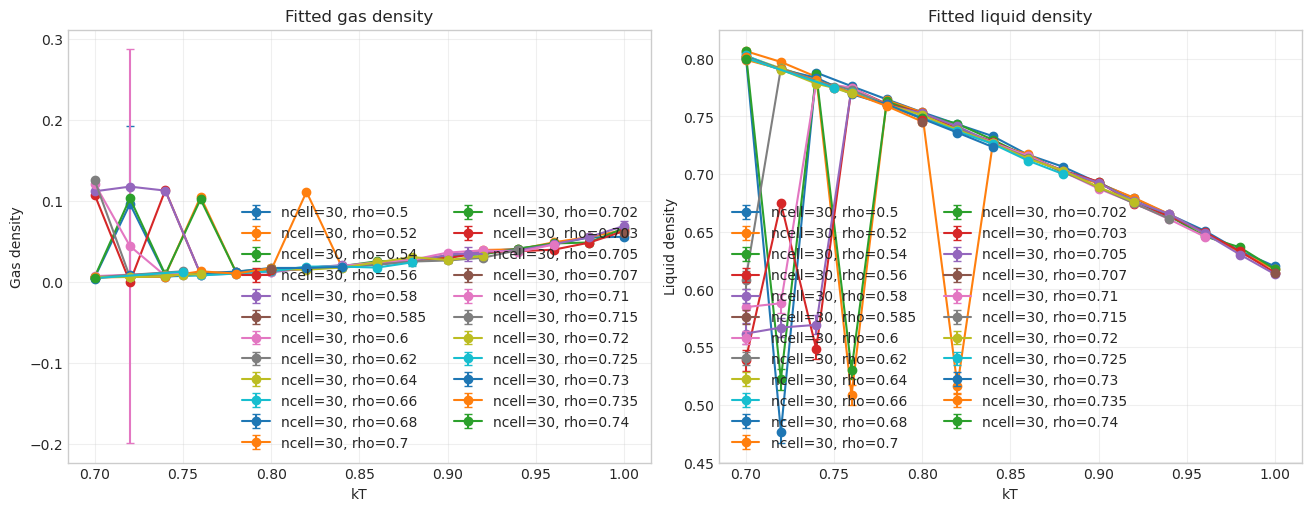

In [39]:
if selected.empty:
    print("No completed fits match the current filters.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    group_columns = ["n_fcc_cells", "target_rho"]
    for (ncell, rho), group in selected.groupby(group_columns, dropna=False):
        group = group.sort_values("kT")
        label = f"ncell={ncell:g}, rho={rho:g}"
        axes[0].errorbar(
            group["kT"], group["gas_density"],
            yerr=group["gas_density_se"], marker="o", capsize=3, label=label,
        )
        axes[1].errorbar(
            group["kT"], group["liquid_density"],
            yerr=group["liquid_density_se"], marker="o", capsize=3, label=label,
        )

    axes[0].set(xlabel="kT", ylabel="Gas density", title="Fitted gas density")
    axes[1].set(xlabel="kT", ylabel="Liquid density", title="Fitted liquid density")
    for axis in axes:
        axis.grid(alpha=0.3)
        axis.legend(ncols=2)
        
    plt.show()

## 6. Liquid/gas density ratio with uncertainty

When the filtered data contain one `ncell`, the x-axis is `kT` and the y-axis is the fitted liquid/gas density ratio. Error bars are one propagated standard error. Different target densities are shown as separate series.

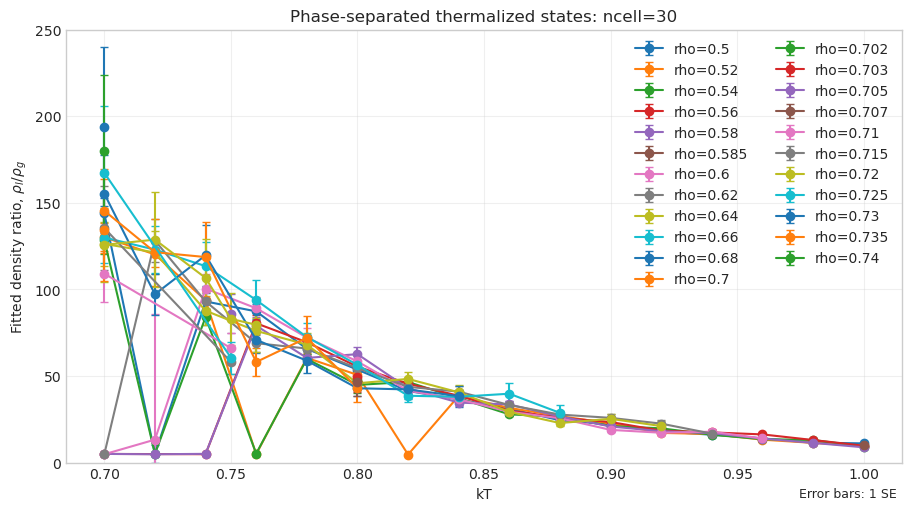

In [38]:
RATIO_BOTTOM = 0
RATIO_TOP = 250

Y_MIN = 0
Y_MAX = 250

ratio = selected["liquid_to_gas_density_ratio"]

plot_selected = selected[
    ratio.between(RATIO_BOTTOM, RATIO_TOP, inclusive="both")
].copy()

if plot_selected.empty:
    print("No completed fits remain after filtering.")
else:
    ax = plot_density_ratio_with_uncertainty(
        plot_selected,
        uncertainty=RATIO_ERROR_BARS,
    )

    ax.set_ylim(Y_MIN, Y_MAX)
    ax.legend(ncol=2)
    plt.show()

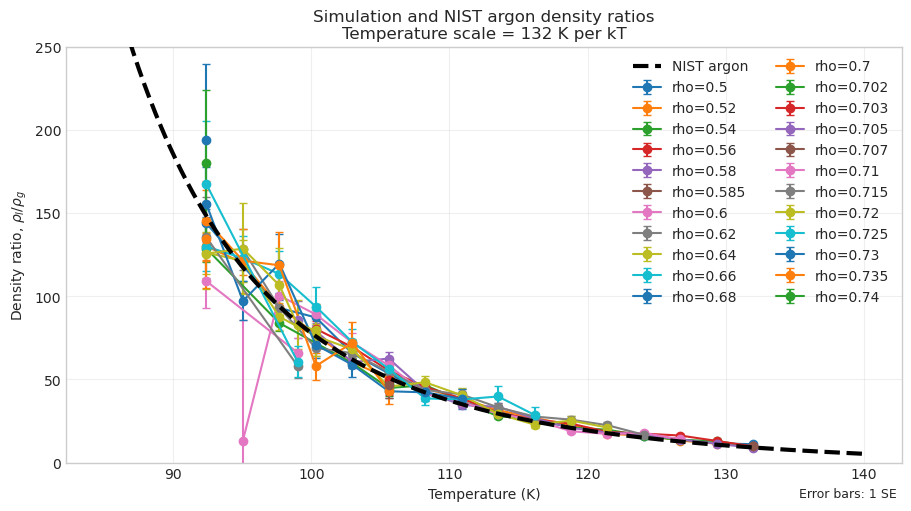

In [40]:
RATIO_BOTTOM = 6
RATIO_TOP = 250

Y_MIN = 0
Y_MAX = 250

# Manually adjust this value to align the curves.
TEMP_SCALE_K_PER_KT = 132.0

ratio = selected["liquid_to_gas_density_ratio"]

plot_selected = selected[
    ratio.between(RATIO_BOTTOM, RATIO_TOP, inclusive="both")
].copy()

# Convert the simulation's reduced kT to kelvin.
plot_selected["kT"] = (
    TEMP_SCALE_K_PER_KT * plot_selected["kT"]
)

# Load the NIST argon saturation data.
argon = pd.read_csv("argon_saturation.tsv", sep="\t")

argon["density_ratio"] = (
    argon["Density (l, mol/l)"]
    / argon["Density (v, mol/l)"]
)

if plot_selected.empty:
    print("No completed fits remain after filtering.")
else:
    # Plot the scaled simulation data.
    ax = plot_density_ratio_with_uncertainty(
        plot_selected,
        uncertainty=RATIO_ERROR_BARS,
    )

    # Overlay the NIST argon curve.
    ax.plot(
        argon["Temperature (K)"],
        argon["density_ratio"],
        color="black",
        linewidth=3,
        linestyle="--",
        label="NIST argon",
        zorder=10,
    )

    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel(r"Density ratio, $\rho_l/\rho_g$")
    ax.set_ylim(Y_MIN, Y_MAX)

    ax.set_title(
        "Simulation and NIST argon density ratios\n"
        f"Temperature scale = {TEMP_SCALE_K_PER_KT:g} K per kT"
    )

    ax.legend(ncol=2)
    plt.show()

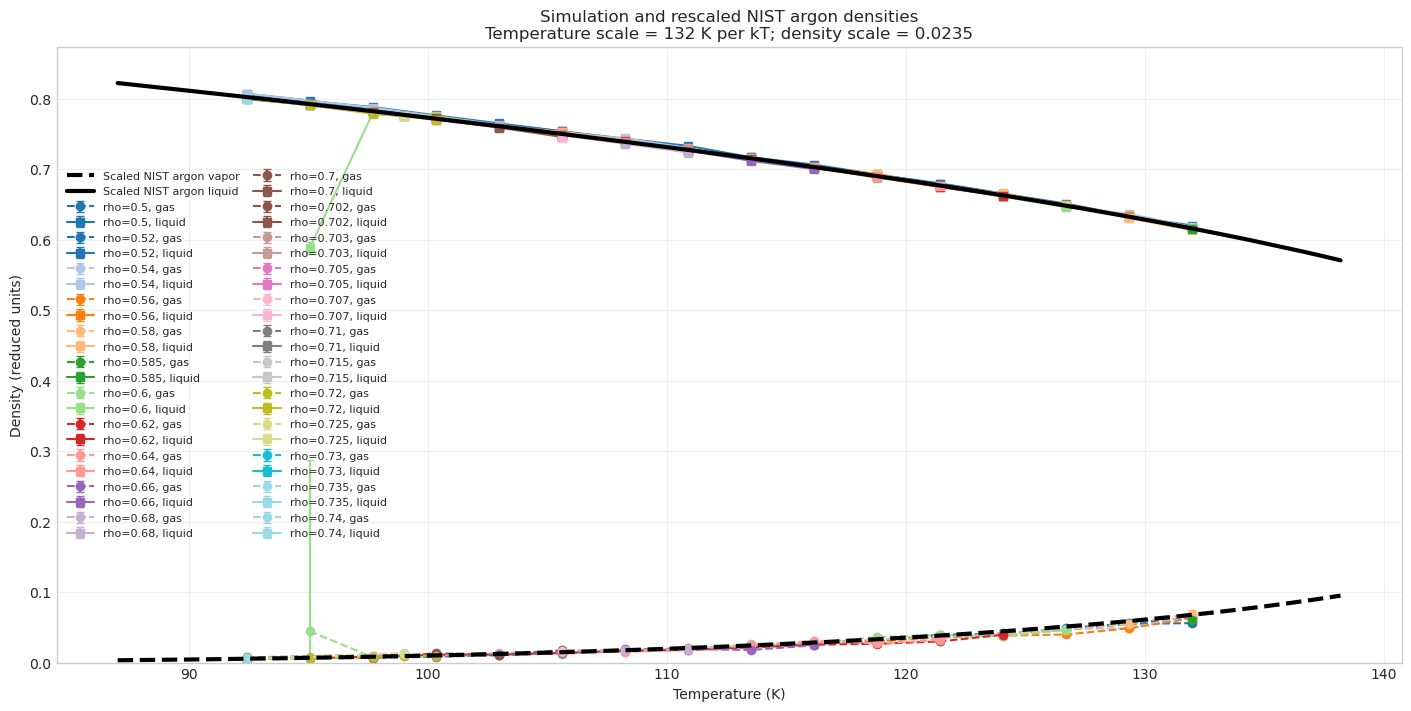

In [17]:
# ============================================================
# User-controlled scaling
# ============================================================

TEMP_SCALE_K_PER_KT = 132.0

# Multiply NIST mol/L by this value to place it on the
# simulation reduced-density axis.
NIST_DENSITY_VERTICAL_SCALE = 0.0235

RATIO_BOTTOM = 6
RATIO_TOP = 250

# Optional plot limits
GAS_Y_MIN = 0
GAS_Y_MAX = None

LIQUID_Y_MIN = 0
LIQUID_Y_MAX = None


# ============================================================
# Apply the ratio mask to the simulation data
# ============================================================

ratio = selected["liquid_to_gas_density_ratio"]

density_selected = selected[
    ratio.between(
        RATIO_BOTTOM,
        RATIO_TOP,
        inclusive="both",
    )
].copy()

# Convert reduced simulation temperature to kelvin.
density_selected["temperature_K"] = (
    TEMP_SCALE_K_PER_KT * density_selected["kT"]
)


# ============================================================
# Apply the same ratio mask to NIST argon
# ============================================================

argon_plot = argon[
    argon["density_ratio"].between(
        RATIO_BOTTOM,
        RATIO_TOP,
        inclusive="both",
    )
].copy()

# Vertically rescale both NIST phases with the same factor.
argon_plot["vapor_density_scaled"] = (
    NIST_DENSITY_VERTICAL_SCALE
    * argon_plot["Density (v, mol/l)"]
)

argon_plot["liquid_density_scaled"] = (
    NIST_DENSITY_VERTICAL_SCALE
    * argon_plot["Density (l, mol/l)"]
)

# ============================================================
# Combined gas and liquid density plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7),
    constrained_layout=True,
)

group_columns = ["n_fcc_cells", "target_rho"]
groups = list(
    density_selected.groupby(
        group_columns,
        dropna=False,
    )
)

colors = plt.cm.tab20(
    np.linspace(0, 1, len(groups))
)

for color, ((ncell, rho), group) in zip(colors, groups):
    group = group.sort_values("temperature_K")

    if RATIO_ERROR_BARS == "se":
        gas_error = group["gas_density_se"]
        liquid_error = group["liquid_density_se"]
    else:
        gas_error = np.vstack([
            group["gas_density"]
            - group["gas_density_ci95_low"],
            group["gas_density_ci95_high"]
            - group["gas_density"],
        ])

        liquid_error = np.vstack([
            group["liquid_density"]
            - group["liquid_density_ci95_low"],
            group["liquid_density_ci95_high"]
            - group["liquid_density"],
        ])

    # Gas: dashed line and circle markers.
    ax.errorbar(
        group["temperature_K"],
        group["gas_density"],
        yerr=gas_error,
        color=color,
        marker="o",
        linestyle="--",
        capsize=3,
        label=f"rho={rho:g}, gas",
    )

    # Liquid: solid line and square markers.
    ax.errorbar(
        group["temperature_K"],
        group["liquid_density"],
        yerr=liquid_error,
        color=color,
        marker="s",
        linestyle="-",
        capsize=3,
        label=f"rho={rho:g}, liquid",
    )


# ============================================================
# Overlay rescaled NIST argon data
# ============================================================

ax.plot(
    argon_plot["Temperature (K)"],
    argon_plot["vapor_density_scaled"],
    color="black",
    linestyle="--",
    linewidth=3,
    label="Scaled NIST argon vapor",
    zorder=10,
)

ax.plot(
    argon_plot["Temperature (K)"],
    argon_plot["liquid_density_scaled"],
    color="black",
    linestyle="-",
    linewidth=3,
    label="Scaled NIST argon liquid",
    zorder=10,
)


# ============================================================
# Formatting
# ============================================================

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Density (reduced units)")

ax.set_title(
    "Simulation and rescaled NIST argon densities\n"
    f"Temperature scale = {TEMP_SCALE_K_PER_KT:g} K per kT; "
    f"density scale = {NIST_DENSITY_VERTICAL_SCALE:g}"
)

ax.set_ylim(
    bottom=min(GAS_Y_MIN, LIQUID_Y_MIN),
    top=(
        None
        if GAS_Y_MAX is None and LIQUID_Y_MAX is None
        else max(
            value
            for value in [GAS_Y_MAX, LIQUID_Y_MAX]
            if value is not None
        )
    ),
)

ax.grid(alpha=0.3)

ax.legend(
    ncol=2,
    fontsize=8,
    columnspacing=1.2,
    handlelength=2.5,
)

plt.show()

## Uncertainty interpretation

The reported uncertainty is the local fit uncertainty from the likelihood Hessian. It includes covariance between fit parameters, but it does not include model-selection uncertainty, sensitivity to voxel resolution, or correlations between neighboring voxels. For legacy single-frame thermalized states, it also cannot measure frame-to-frame variation. Use `frames_fitted` when interpreting or filtering the results.